# Team #6 — Sentiment Analysis: Phase 2
### COMP 262 · Cloud Machine Learning · Dr. Sajid Hussain
**Dataset:** Amazon Product Reviews — Software (5-core)

| Step | Description | Author |
|------|-------------|--------|
| 11a | Dataset Selection & Subset Exploration | Omair Khan |
| 11b | Data Preprocessing | Omair Khan |
| 11c | Text Representation (TF-IDF) | Ryan Frederick |
| 11d | Train / Test Split (70/30, stratified) | Ryan Frederick |
| 11e | Model Development: LR + LinearSVC | Ryan Frederick |
| 12 | Training Results Summary | Ryan Frederick |
| 13 | Testing & Evaluation | Hardiksinh Zala |
| 14 | Apples-to-Apples: Lexicon vs ML | Hardiksinh Zala |
| 15 | Recommender System Enhancement | Ajmal Afzalzada |
| 16 | LLM Summarization (BART) | Ajmal Afzalzada |
| 17 | LLM Response Generation (Flan-T5) | Ajmal Afzalzada |

---
> **Before running:** upload `Software_5.json` using the cell below, or mount Google Drive if the file is already there.

## 📁 Upload Dataset
Run this cell to upload `Software_5.json` from your computer, or skip it if you are loading from Google Drive.

In [1]:
# Option A — Upload from your computer
from google.colab import files
uploaded = files.upload()   # select Software_5.json when prompted

# Option B — Mount Google Drive (comment out Option A and uncomment below)
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# os.chdir('/content/drive/MyDrive/')  # adjust path to where your file lives

## 0. Install & Import Dependencies

In [2]:
import subprocess, sys

packages = ['scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'nltk']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import json, os, re, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

for resource in ['stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Imports complete.')

Imports complete.


## Step 11(a) — Dataset Selection
**Author: Omair Khan**

Load the Amazon Software review dataset (JSON Lines format). Keep only the fields needed for sentiment analysis, map star ratings to sentiment labels, and draw a stratified random sample of **3,000 reviews** (exceeds the 2,000-review minimum).

In [4]:
JSON_CANDIDATES = ['Software_5.json', 'Software_5_1.json']
data = []

for fname in JSON_CANDIDATES:
    if os.path.exists(fname):
        print(f'Loading {fname}...')
        with open(fname, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    data.append(json.loads(line))
        break
else:
    raise FileNotFoundError(
        'Dataset not found! Upload Software_5.json using the cell above.\n'
        'Download: https://nijianmo.github.io/amazon/index.html'
    )

df = pd.DataFrame(data)
df = df[['reviewText', 'summary', 'overall']].copy()
df.dropna(subset=['reviewText', 'overall'], inplace=True)
df['text'] = df['summary'].fillna('') + ' ' + df['reviewText'].fillna('')
df['text'] = df['text'].str.strip()
df = df[df['text'] != '']

def map_sentiment(rating):
    if rating in [1, 2]:  return 'negative'
    elif rating == 3:      return 'neutral'
    elif rating in [4, 5]: return 'positive'

df['sentiment'] = df['overall'].apply(map_sentiment)

SEED = 42
df_subset = df.sample(n=3000, random_state=SEED).reset_index(drop=True)

print('Selected subset shape:', df_subset.shape)
print('\nSentiment distribution:')
print(df_subset['sentiment'].value_counts())

df_subset['review_length_words'] = df_subset['text'].apply(lambda x: len(x.split()))
print('\nReview length statistics (words):')
print(df_subset['review_length_words'].describe())

Loading Software_5.json...
Selected subset shape: (3000, 5)

Sentiment distribution:
sentiment
positive    2104
negative     504
neutral      392
Name: count, dtype: int64

Review length statistics (words):
count    3000.000000
mean      180.197667
std       247.463981
min         2.000000
25%        37.000000
50%       107.000000
75%       235.000000
max      5037.000000
Name: review_length_words, dtype: float64


### Subset Data Exploration
Rating distribution, review length analysis, and duplicate check.

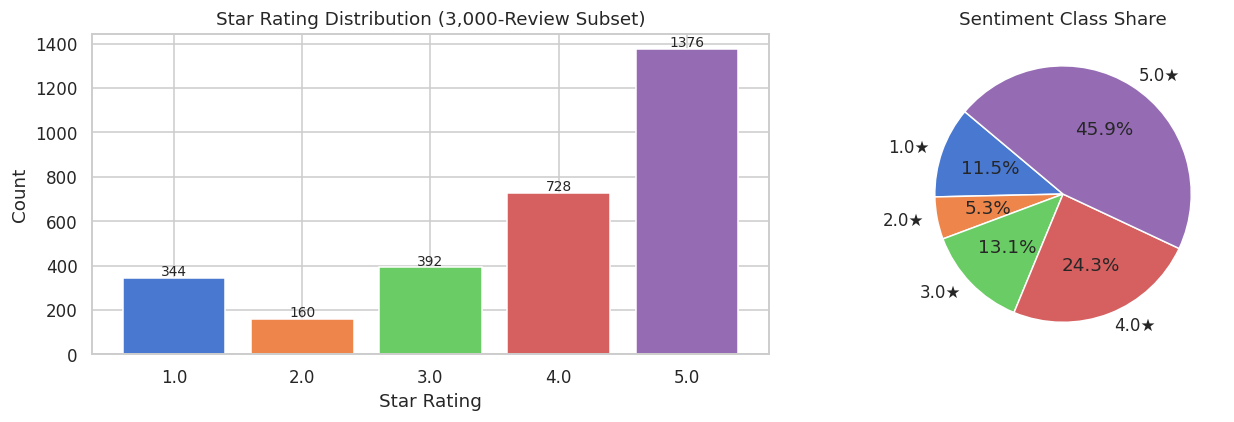

Review length outliers (above 99th pct = 1143 words): 30
95th percentile length : 589 words


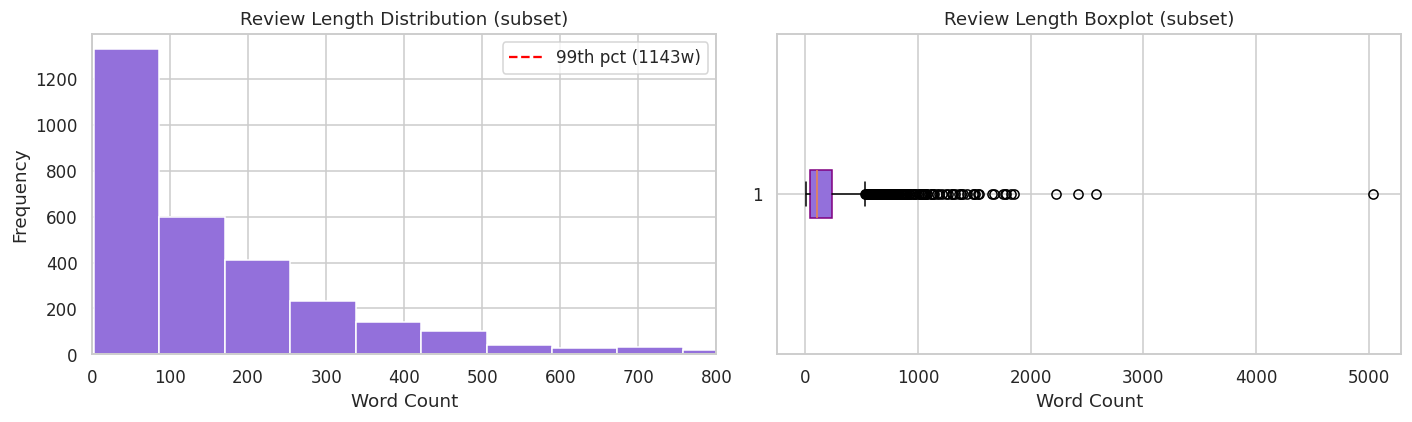


Duplicate combined texts  : 176
Duplicate (text+summary)  : 176
Duplicates removed. Subset size now: 2,824


In [5]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rating_counts = df_subset['overall'].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(str), rating_counts.values,
            color=sns.color_palette('muted'), edgecolor='white')
axes[0].set_title('Star Rating Distribution (3,000-Review Subset)')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')
for i, v in enumerate(rating_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)
axes[1].pie(rating_counts.values,
            labels=[f'{r}\u2605' for r in rating_counts.index],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('muted', len(rating_counts)))
axes[1].set_title('Sentiment Class Share')
plt.tight_layout()
plt.savefig('step11a_subset_rating_distribution.png', bbox_inches='tight')
plt.show()

# Review length distribution + outlier detection
p95 = df_subset['review_length_words'].quantile(0.95)
p99 = df_subset['review_length_words'].quantile(0.99)
outliers_count = (df_subset['review_length_words'] > p99).sum()
print(f'Review length outliers (above 99th pct = {p99:.0f} words): {outliers_count}')
print(f'95th percentile length : {p95:.0f} words')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_subset['review_length_words'], bins=60, color='mediumpurple', edgecolor='white')
axes[0].axvline(p99, color='red', linestyle='--', lw=1.5, label=f'99th pct ({p99:.0f}w)')
axes[0].set_xlim(0, 800)
axes[0].set_title('Review Length Distribution (subset)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[1].boxplot(df_subset['review_length_words'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='mediumpurple', color='purple'))
axes[1].set_title('Review Length Boxplot (subset)')
axes[1].set_xlabel('Word Count')
plt.tight_layout()
plt.savefig('step11a_subset_review_length.png', bbox_inches='tight')
plt.show()

# Duplicate check
dup_text = df_subset['text'].duplicated().sum()
dup_pair = df_subset.duplicated(subset=['reviewText', 'summary']).sum()
print(f'\nDuplicate combined texts  : {dup_text}')
print(f'Duplicate (text+summary)  : {dup_pair}')
if dup_text > 0:
    df_subset = df_subset[~df_subset['text'].duplicated()].copy()
    print(f'Duplicates removed. Subset size now: {len(df_subset):,}')
else:
    print('No duplicates found — subset is clean.')

## Step 11(b) — Data Preprocessing
**Author: Omair Khan**

Five-step pipeline applied to all reviews:
1. **Lowercase** — normalises capitalisation
2. **Remove punctuation/digits/special chars** — strips non-letter noise via `[^a-z\s]`
3. **Tokenize** — whitespace split
4. **Remove stopwords** — NLTK English stop-word list
5. **Lemmatize** — reduces words to base form (e.g. *crashes* → *crash*)

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df_subset['clean_text'] = df_subset['text'].apply(preprocess_text)

print('Sample before and after preprocessing:')
for i in range(3):
    print(f'\n[Review {i+1}]')
    print('  Original :', df_subset.iloc[i]['text'][:200])
    print('  Cleaned  :', df_subset.iloc[i]['clean_text'][:200])

df_subset.to_csv('phase2_subset_preprocessed.csv', index=False)
print('\nPreprocessed dataset saved as: phase2_subset_preprocessed.csv')

Sample before and after preprocessing:

[Review 1]
  Original : I really love this reading program and I use it for my ... I really love this reading program and I use it for my 3 year old grandson whom I'm helping to learn to read.  The games are engaging enough 
  Cleaned  : really love reading program use really love reading program use year old grandson helping learn read game engaging enough allow play independently minute provide prompting easy install window tested p

[Review 2]
  Original : tax software Used it this year and it did what it was suppose to do help me fill my taxes what more can be said about this program
  Cleaned  : tax software used year suppose help fill tax said program

[Review 3]
  Original : Leaps and Bounds Ahead of the Old Versions I had version 7-- and wrote a pretty scathing review on Amazon, if you care to look. But I still had a need for voice recognition software to transcribe inte
  Cleaned  : leap bound ahead old version version wrote pretty scath

## Step 11(c) — Text Representation (TF-IDF)
**Author: Ryan Frederick**

TF-IDF (Term Frequency–Inverse Document Frequency) converts cleaned text into a numerical feature matrix.
Settings chosen:
- `stop_words='english'` — removes common English words
- `max_features=50,000` — caps vocabulary to top 50k terms
- `ngram_range=(1,2)` — unigrams + bigrams (captures phrases like *"not good"*)
- `sublinear_tf=True` — applies log(1+tf) to dampen high-frequency terms

The vectoriser is fitted **only on X_train** inside the sklearn Pipeline, preventing data leakage.

In [7]:
TFIDF_PARAMS = dict(
    stop_words='english',
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
)
print('TF-IDF settings:', TFIDF_PARAMS)

TF-IDF settings: {'stop_words': 'english', 'max_features': 50000, 'ngram_range': (1, 2), 'sublinear_tf': True}


## Step 11(d) — Train / Test Split
**Author: Ryan Frederick**

70% training / 30% test with **stratified sampling** to preserve class proportions in both splits.

In [8]:
df_subset['label'] = df_subset['sentiment'].str.capitalize()
CLASSES = ['Positive', 'Neutral', 'Negative']

X = df_subset['clean_text']
y = df_subset['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

print(f'Train set: {len(X_train):,} reviews (70%)')
print(f'Test  set: {len(X_test):,} reviews (30%)')
print('\nTrain label distribution:')
print(y_train.value_counts())
print('\nTest label distribution:')
print(y_test.value_counts())

Train set: 1,976 reviews (70%)
Test  set: 848 reviews (30%)

Train label distribution:
label
Positive    1375
Negative     335
Neutral      266
Name: count, dtype: int64

Test label distribution:
label
Positive    590
Negative    144
Neutral     114
Name: count, dtype: int64


## Step 11(e) — Model Development
**Author: Ryan Frederick**

### Model 1: Logistic Regression
Logistic Regression is a linear probabilistic classifier well-suited to TF-IDF feature spaces.
Regularisation strength C is swept across [0.1, 0.5, 1.0, 5.0] to find the optimal value.

In [9]:
print('Hyperparameter sweep — C values: [0.1, 0.5, 1.0, 5.0]')
print(f'{"C":<8} {"Accuracy":>10} {"F1-W":>10}')
print('-'*30)
lr_results = {}
for C in [0.1, 0.5, 1.0, 5.0]:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LogisticRegression(C=C, max_iter=1000, random_state=SEED,
                                     class_weight='balanced', solver='lbfgs'))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    lr_results[C] = (acc, f1w)
    print(f'{C:<8} {acc:>10.4f} {f1w:>10.4f}')

best_C_lr = max(lr_results, key=lambda c: lr_results[c][1])
print(f'\n  Best C = {best_C_lr}  (F1-W = {lr_results[best_C_lr][1]:.4f})')

lr_final = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',   LogisticRegression(C=best_C_lr, max_iter=1000, random_state=SEED,
                                 class_weight='balanced', solver='lbfgs'))
])
t0 = time.time()
lr_final.fit(X_train, y_train)
lr_train_time = time.time() - t0

y_pred_lr = lr_final.predict(X_test)
lr_acc  = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, labels=CLASSES, average='weighted', zero_division=0)
lr_rec  = recall_score(y_test, y_pred_lr, labels=CLASSES, average='weighted', zero_division=0)
lr_f1   = f1_score(y_test, y_pred_lr, labels=CLASSES, average='weighted', zero_division=0)
lr_cm   = confusion_matrix(y_test, y_pred_lr, labels=CLASSES)

print(f'\nBest LR config : C={best_C_lr}, solver=lbfgs, class_weight=balanced')
print(f'Training time  : {lr_train_time:.2f}s')
print(f'Test Accuracy  : {lr_acc:.4f}')
print(f'Precision (W)  : {lr_prec:.4f}')
print(f'Recall (W)     : {lr_rec:.4f}')
print(f'F1 (W)         : {lr_f1:.4f}')
print('\nPer-class Classification Report:')
print(classification_report(y_test, y_pred_lr, labels=CLASSES, zero_division=0))
print('Confusion Matrix (rows=Actual, cols=Predicted):')
print(pd.DataFrame(lr_cm, index=CLASSES, columns=CLASSES).to_string())

Hyperparameter sweep — C values: [0.1, 0.5, 1.0, 5.0]
C          Accuracy       F1-W
------------------------------
0.1          0.6226     0.6561
0.5          0.6722     0.6911
1.0          0.7017     0.7104
5.0          0.7217     0.7150

  Best C = 5.0  (F1-W = 0.7150)

Best LR config : C=5.0, solver=lbfgs, class_weight=balanced
Training time  : 7.56s
Test Accuracy  : 0.7217
Precision (W)  : 0.7094
Recall (W)     : 0.7217
F1 (W)         : 0.7150

Per-class Classification Report:
              precision    recall  f1-score   support

    Positive       0.82      0.84      0.83       590
     Neutral       0.29      0.24      0.26       114
    Negative       0.59      0.61      0.60       144

    accuracy                           0.72       848
   macro avg       0.57      0.56      0.56       848
weighted avg       0.71      0.72      0.72       848

Confusion Matrix (rows=Actual, cols=Predicted):
          Positive  Neutral  Negative
Positive       497       50        43
Neutral 

### Model 2: LinearSVC (Support Vector Machine)
LinearSVC finds the maximum-margin hyperplane in the TF-IDF feature space.
C is swept across [0.01, 0.1, 0.5, 1.0, 5.0].

In [10]:
print('Hyperparameter sweep — C values: [0.01, 0.1, 0.5, 1.0, 5.0]')
print(f'{"C":<8} {"Accuracy":>10} {"F1-W":>10}')
print('-'*30)
svm_results = {}
for C in [0.01, 0.1, 0.5, 1.0, 5.0]:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LinearSVC(C=C, random_state=SEED, class_weight='balanced', max_iter=3000))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    svm_results[C] = (acc, f1w)
    print(f'{C:<8} {acc:>10.4f} {f1w:>10.4f}')

best_C_svm = max(svm_results, key=lambda c: svm_results[c][1])
print(f'\n  Best C = {best_C_svm}  (F1-W = {svm_results[best_C_svm][1]:.4f})')

svm_final = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',   LinearSVC(C=best_C_svm, random_state=SEED, class_weight='balanced', max_iter=3000))
])
t0 = time.time()
svm_final.fit(X_train, y_train)
svm_train_time = time.time() - t0

y_pred_svm = svm_final.predict(X_test)
svm_acc  = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm, labels=CLASSES, average='weighted', zero_division=0)
svm_rec  = recall_score(y_test, y_pred_svm, labels=CLASSES, average='weighted', zero_division=0)
svm_f1   = f1_score(y_test, y_pred_svm, labels=CLASSES, average='weighted', zero_division=0)
svm_cm   = confusion_matrix(y_test, y_pred_svm, labels=CLASSES)

print(f'\nBest SVM config: C={best_C_svm}, linear kernel, class_weight=balanced')
print(f'Training time  : {svm_train_time:.2f}s')
print(f'Test Accuracy  : {svm_acc:.4f}')
print(f'Precision (W)  : {svm_prec:.4f}')
print(f'Recall (W)     : {svm_rec:.4f}')
print(f'F1 (W)         : {svm_f1:.4f}')
print('\nPer-class Classification Report:')
print(classification_report(y_test, y_pred_svm, labels=CLASSES, zero_division=0))
print('Confusion Matrix (rows=Actual, cols=Predicted):')
print(pd.DataFrame(svm_cm, index=CLASSES, columns=CLASSES).to_string())

Hyperparameter sweep — C values: [0.01, 0.1, 0.5, 1.0, 5.0]
C          Accuracy       F1-W
------------------------------
0.01         0.6958     0.5709
0.1          0.7441     0.6902
0.5          0.7429     0.7164
1.0          0.7382     0.7137
5.0          0.7335     0.7107

  Best C = 0.5  (F1-W = 0.7164)

Best SVM config: C=0.5, linear kernel, class_weight=balanced
Training time  : 0.79s
Test Accuracy  : 0.7429
Precision (W)  : 0.7050
Recall (W)     : 0.7429
F1 (W)         : 0.7164

Per-class Classification Report:
              precision    recall  f1-score   support

    Positive       0.79      0.91      0.85       590
     Neutral       0.33      0.15      0.20       114
    Negative       0.64      0.55      0.59       144

    accuracy                           0.74       848
   macro avg       0.59      0.53      0.55       848
weighted avg       0.71      0.74      0.72       848

Confusion Matrix (rows=Actual, cols=Predicted):
          Positive  Neutral  Negative
Positive

## Step 12 — Training Results Summary
**Author: Ryan Frederick**

                      Logistic Regression  LinearSVC (SVM)
Metric                                                    
Accuracy                           0.7217           0.7429
Precision (weighted)               0.7094           0.7050
Recall (weighted)                  0.7217           0.7429
F1 (weighted)                      0.7150           0.7164
Training Time (s)                  7.5600           0.7900


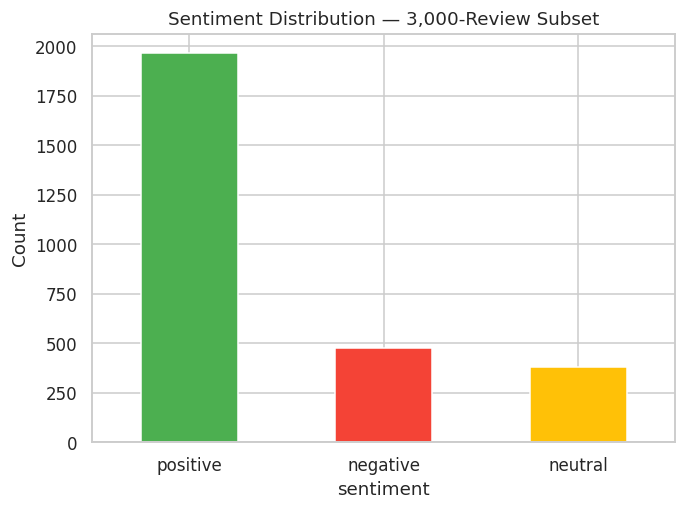

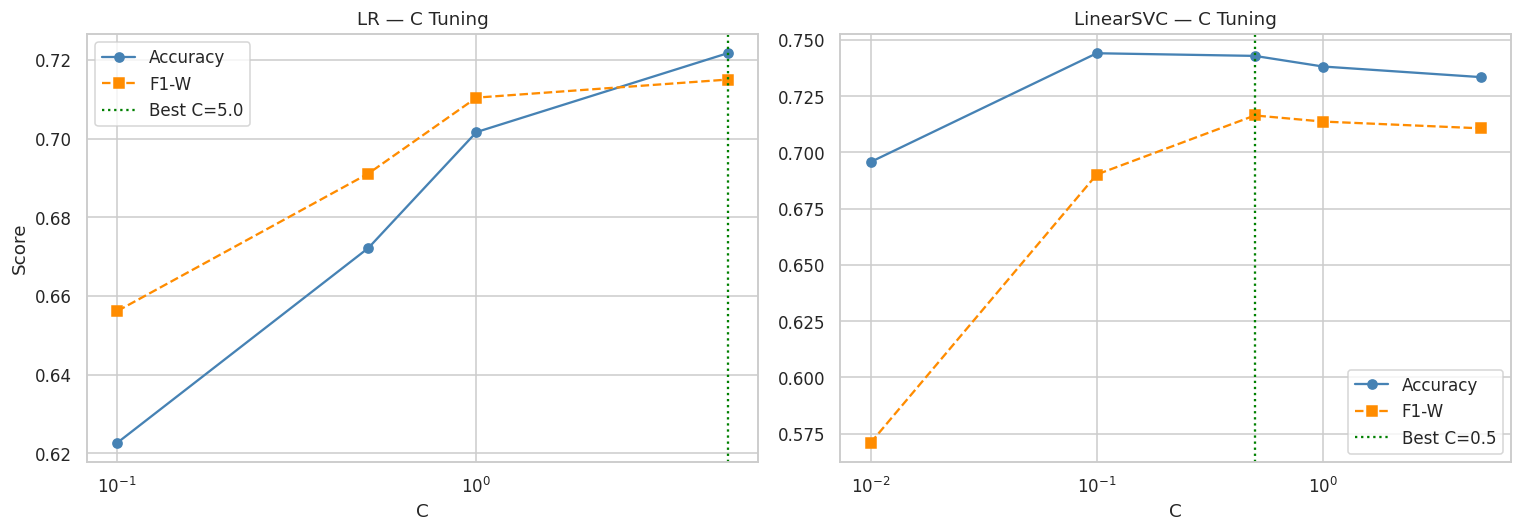

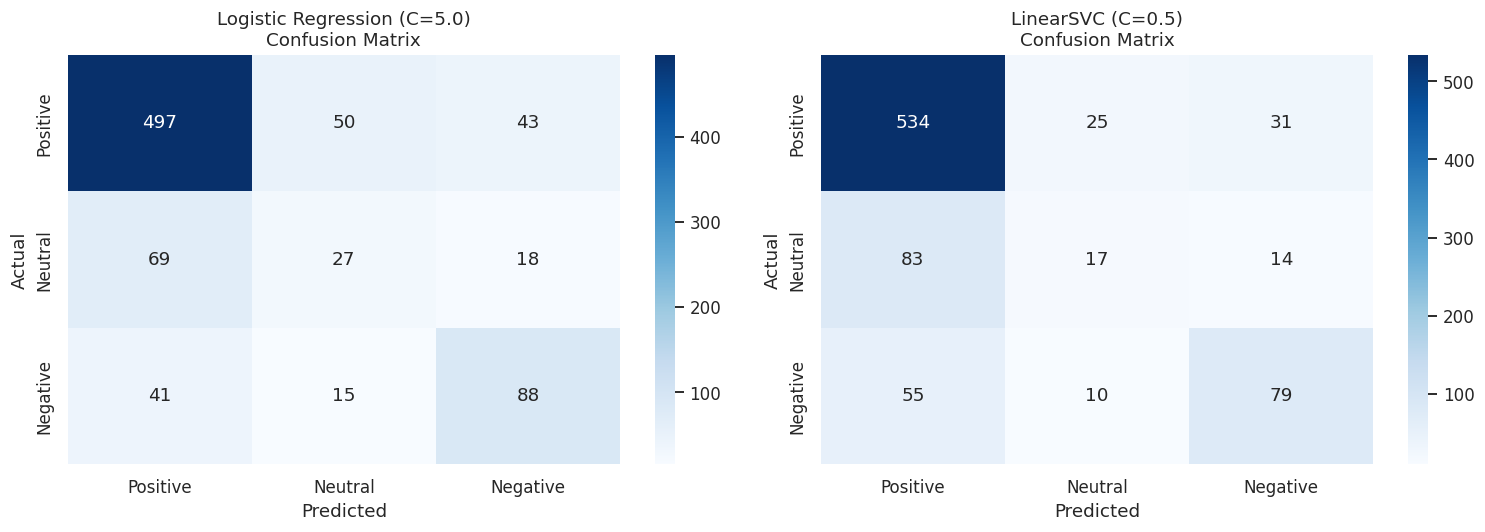

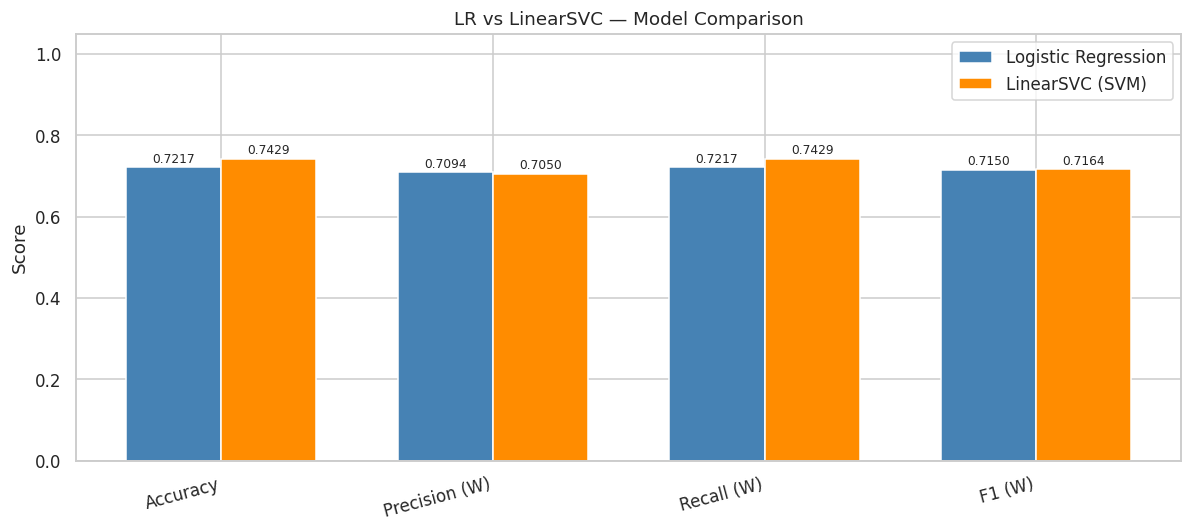

Saved: team6_phase2_model_comparison.png


In [11]:
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1 (weighted)', 'Training Time (s)'],
    'Logistic Regression': [round(lr_acc,4), round(lr_prec,4), round(lr_rec,4), round(lr_f1,4), round(lr_train_time,2)],
    'LinearSVC (SVM)':     [round(svm_acc,4), round(svm_prec,4), round(svm_rec,4), round(svm_f1,4), round(svm_train_time,2)]
}).set_index('Metric')
print(summary.to_string())
summary.to_csv('team6_phase2_model_comparison.csv')

# Sentiment distribution bar
df_subset['sentiment'].value_counts().plot(
    kind='bar', color=['#4CAF50','#F44336','#FFC107'],
    title='Sentiment Distribution — 3,000-Review Subset')
plt.xticks(rotation=0); plt.ylabel('Count'); plt.tight_layout(); plt.show()

# Hyperparameter tuning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lr_Cs = sorted(lr_results.keys())
axes[0].plot(lr_Cs, [lr_results[c][0] for c in lr_Cs], 'o-', label='Accuracy', color='steelblue')
axes[0].plot(lr_Cs, [lr_results[c][1] for c in lr_Cs], 's--', label='F1-W', color='darkorange')
axes[0].axvline(best_C_lr, color='green', linestyle=':', lw=1.5, label=f'Best C={best_C_lr}')
axes[0].set_xscale('log'); axes[0].set_title('LR — C Tuning')
axes[0].set_xlabel('C'); axes[0].set_ylabel('Score'); axes[0].legend()
svm_Cs = sorted(svm_results.keys())
axes[1].plot(svm_Cs, [svm_results[c][0] for c in svm_Cs], 'o-', label='Accuracy', color='steelblue')
axes[1].plot(svm_Cs, [svm_results[c][1] for c in svm_Cs], 's--', label='F1-W', color='darkorange')
axes[1].axvline(best_C_svm, color='green', linestyle=':', lw=1.5, label=f'Best C={best_C_svm}')
axes[1].set_xscale('log'); axes[1].set_title('LinearSVC — C Tuning')
axes[1].set_xlabel('C'); axes[1].legend()
plt.tight_layout(); plt.savefig('team6_phase2_hyperparameter_tuning.png', bbox_inches='tight'); plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title in zip(axes, [lr_cm, svm_cm],
                          [f'Logistic Regression (C={best_C_lr})', f'LinearSVC (C={best_C_svm})']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(f'{title}\nConfusion Matrix'); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.savefig('team6_phase2_confusion_matrices.png', bbox_inches='tight'); plt.show()

# Bar chart comparison
metrics_labels = ['Accuracy','Precision (W)','Recall (W)','F1 (W)']
lr_vals  = [lr_acc, lr_prec, lr_rec, lr_f1]
svm_vals = [svm_acc, svm_prec, svm_rec, svm_f1]
x = np.arange(len(metrics_labels)); width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, lr_vals,  width, label='Logistic Regression', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, svm_vals, width, label='LinearSVC (SVM)',     color='darkorange', edgecolor='white')
for bar in list(bars1)+list(bars2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
ax.set_ylim(0,1.05); ax.set_title('LR vs LinearSVC — Model Comparison')
ax.set_ylabel('Score'); ax.set_xticks(x); ax.set_xticklabels(metrics_labels, rotation=15, ha='right')
ax.legend(); plt.tight_layout()
plt.savefig('team6_phase2_model_comparison.png', bbox_inches='tight'); plt.show()
print('Saved: team6_phase2_model_comparison.png')

## Step 14 — Apples-to-Apples: Lexicon vs ML
**Author: Hardiksinh Zala**

To compare fairly, we draw the **same 1,000-review sample** used in Phase 1 (same `random_state=42`), run all four models on it, and compare using identical metrics.


  VADER (lexicon)
              precision    recall  f1-score   support

    Positive       0.78      0.92      0.84       702
     Neutral       0.13      0.04      0.07       135
    Negative       0.55      0.44      0.49       163

    accuracy                           0.72      1000
   macro avg       0.49      0.47      0.47      1000
weighted avg       0.66      0.72      0.68      1000


  TextBlob (lexicon)
              precision    recall  f1-score   support

    Positive       0.76      0.89      0.82       702
     Neutral       0.18      0.17      0.17       135
    Negative       0.60      0.20      0.30       163

    accuracy                           0.68      1000
   macro avg       0.51      0.42      0.43      1000
weighted avg       0.66      0.68      0.65      1000


  Logistic Regression (ML)
              precision    recall  f1-score   support

    Positive       0.95      0.96      0.95       702
     Neutral       0.82      0.79      0.80       135
    Ne

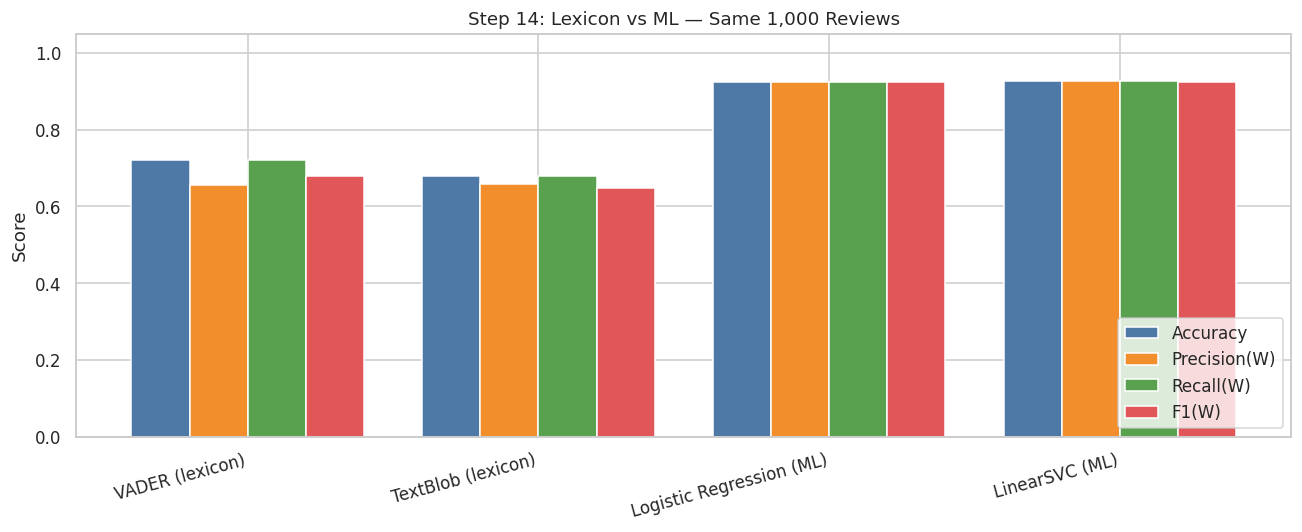

Saved: step14_all_model_comparison.png


In [12]:
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'vaderSentiment', 'textblob', '-q'])
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

df_sample = df.sample(n=1000, random_state=SEED).reset_index(drop=True)
df_sample['label'] = df_sample['sentiment'].str.capitalize()
df_sample['clean_text'] = df_sample['text'].apply(preprocess_text)
y_sample_true = df_sample['label']

def clean_vader(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df_sample['text_vader']    = df_sample['text'].apply(clean_vader)
df_sample['text_textblob'] = df_sample['clean_text']

va = SentimentIntensityAnalyzer()
def vader_predict(text):
    c = va.polarity_scores(text)['compound']
    return 'Positive' if c >= 0.05 else ('Negative' if c <= -0.05 else 'Neutral')

def tb_predict(text):
    p = TextBlob(text).sentiment.polarity
    return 'Positive' if p > 0.05 else ('Negative' if p < -0.05 else 'Neutral')

df_sample['vader_pred'] = df_sample['text_vader'].apply(vader_predict)
df_sample['tb_pred']    = df_sample['text_textblob'].apply(tb_predict)
df_sample['lr_pred']    = lr_final.predict(df_sample['clean_text'])
df_sample['svm_pred']   = svm_final.predict(df_sample['clean_text'])

def eval_model(y_true, y_pred, name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, labels=CLASSES, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, labels=CLASSES, average='weighted', zero_division=0)
    f1w  = f1_score(y_true, y_pred, labels=CLASSES, average='weighted', zero_division=0)
    print(f'\n  {name}')
    print(classification_report(y_true, y_pred, labels=CLASSES, zero_division=0))
    return {'Model': name, 'Accuracy': round(acc,4), 'Precision(W)': round(prec,4),
            'Recall(W)': round(rec,4), 'F1(W)': round(f1w,4)}

rows = []
rows.append(eval_model(y_sample_true, df_sample['vader_pred'], 'VADER (lexicon)'))
rows.append(eval_model(y_sample_true, df_sample['tb_pred'],    'TextBlob (lexicon)'))
rows.append(eval_model(y_sample_true, df_sample['lr_pred'],    'Logistic Regression (ML)'))
rows.append(eval_model(y_sample_true, df_sample['svm_pred'],   'LinearSVC (ML)'))

comparison_df = pd.DataFrame(rows).set_index('Model')
print('\n=== All-Model Comparison on 1,000-Review Sample ===')
print(comparison_df.to_string())
comparison_df.to_csv('step14_model_comparison.csv')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison_df))
metrics_14 = ['Accuracy','Precision(W)','Recall(W)','F1(W)']
colors_14  = ['#4e79a7','#f28e2b','#59a14f','#e15759']
width_14   = 0.2
for i, (metric, color) in enumerate(zip(metrics_14, colors_14)):
    ax.bar(x + i*width_14, comparison_df[metric], width_14, label=metric, color=color, edgecolor='white')
ax.set_xticks(x + width_14*1.5)
ax.set_xticklabels(comparison_df.index, rotation=15, ha='right')
ax.set_ylim(0,1.05); ax.set_title('Step 14: Lexicon vs ML — Same 1,000 Reviews')
ax.set_ylabel('Score'); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig('step14_all_model_comparison.png', bbox_inches='tight'); plt.show()
print('Saved: step14_all_model_comparison.png')

## Step 15 — Recommender System Enhancement
**Author: Ajmal Afzalzada**

**Approach:** Sentiment-Adjusted Rating (Pero & Horvath, 2013; Section 4.3.3 of Chen, Chen & Wang, 2015)

**Formula:** `Adjusted Rating = CLIP(Original Rating + λ × sentiment_score, 1.0, 5.0)`

| Predicted Sentiment | Score | λ |
|---|---|---|
| Positive | +1 | 0.5 |
| Neutral | 0 | 0.5 |
| Negative | −1 | 0.5 |

**Pseudocode:**
```
LAMBDA = 0.5
SENTIMENT_MAP = {Positive: +1, Neutral: 0, Negative: -1}

FOR each review in dataset:
    sentiment_label = SVM_model.predict(review.clean_text)
    sentiment_score = SENTIMENT_MAP[sentiment_label]
    adjusted_rating = original_rating + (LAMBDA × sentiment_score)
    adjusted_rating = CLIP(adjusted_rating, min=1.0, max=5.0)
```

Original rating mean    : 3.8545
Adjusted rating mean    : 3.9703
Ratings increased (+0.5): 821
Ratings decreased (-0.5): 167
Ratings unchanged       : 1,836

Sample Results (10 rows):
                                                               reviewText  overall sentiment_pred  adjusted_rating
I really love this reading program and I use it for my 3 year old gran...      5.0       Positive              5.0
Used it this year and it did what it was suppose to do help me fill my...      4.0       Positive              4.5
I had version 7-- and wrote a pretty scathing review on Amazon, if you...      4.0       Positive              4.5
Windows 8 is the worst mistake in Microsoft's history.  How sad.  Afte...      1.0       Negative              1.0
Most people know that Sage 50 in its various incarnations is the evolu...      4.0       Positive              4.5
It does its job, no problems, I got my refund in 9 days. Nothing much ...      3.0        Neutral              3.0
          

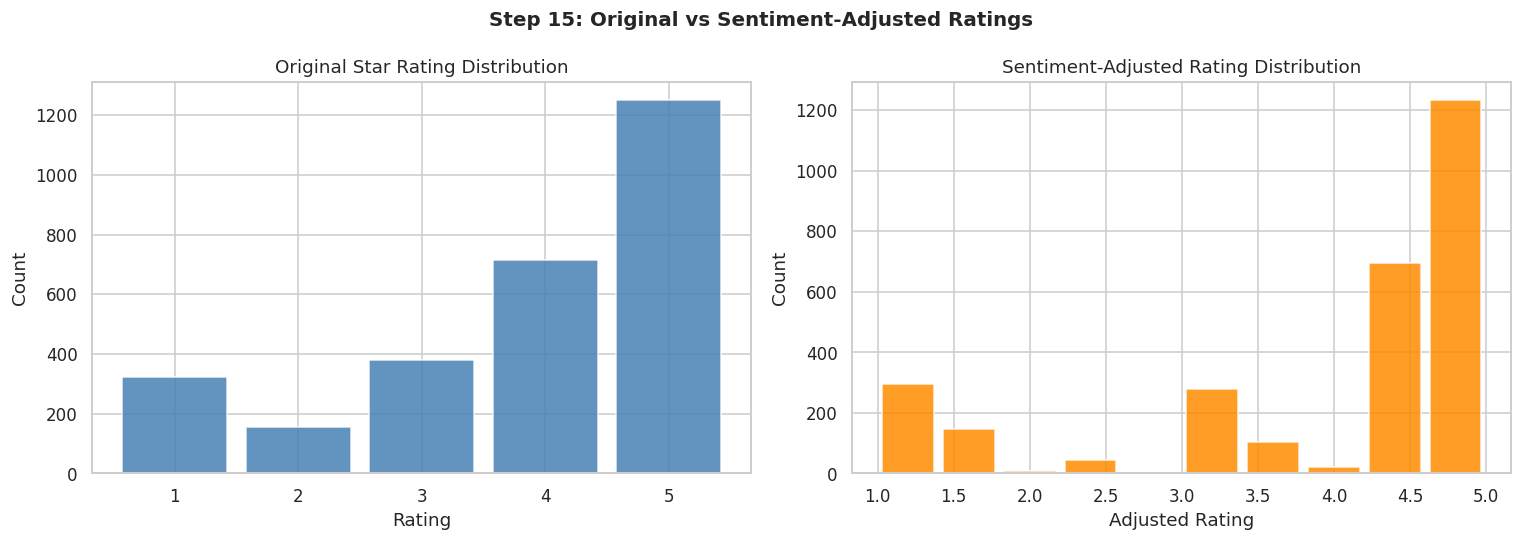

Saved: step15_adjusted_ratings.csv


In [13]:
LAMBDA        = 0.5
SENTIMENT_MAP = {'Positive': 1, 'Neutral': 0, 'Negative': -1}

df_subset['sentiment_pred']  = svm_final.predict(df_subset['clean_text'])
df_subset['sentiment_score'] = df_subset['sentiment_pred'].map(SENTIMENT_MAP)
df_subset['adjusted_rating'] = (
    df_subset['overall'] + LAMBDA * df_subset['sentiment_score']
).clip(1.0, 5.0)

print(f'Original rating mean    : {df_subset["overall"].mean():.4f}')
print(f'Adjusted rating mean    : {df_subset["adjusted_rating"].mean():.4f}')
print(f'Ratings increased (+0.5): {(df_subset["adjusted_rating"] > df_subset["overall"]).sum():,}')
print(f'Ratings decreased (-0.5): {(df_subset["adjusted_rating"] < df_subset["overall"]).sum():,}')
print(f'Ratings unchanged       : {(df_subset["adjusted_rating"] == df_subset["overall"]).sum():,}')

sample_out = df_subset[['reviewText','overall','sentiment_pred','adjusted_rating']].head(10).copy()
sample_out['reviewText'] = sample_out['reviewText'].str[:70] + '...'
print('\nSample Results (10 rows):')
print(sample_out.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_subset['overall'].astype(float), bins=[0.5,1.5,2.5,3.5,4.5,5.5],
             color='steelblue', alpha=0.85, edgecolor='white', rwidth=0.85)
axes[0].set_title('Original Star Rating Distribution')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count'); axes[0].set_xticks([1,2,3,4,5])
axes[1].hist(df_subset['adjusted_rating'], bins=10, color='darkorange', alpha=0.85, edgecolor='white', rwidth=0.85)
axes[1].set_title('Sentiment-Adjusted Rating Distribution')
axes[1].set_xlabel('Adjusted Rating'); axes[1].set_ylabel('Count')
plt.suptitle('Step 15: Original vs Sentiment-Adjusted Ratings', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('step15_adjusted_ratings.png', bbox_inches='tight'); plt.show()

df_subset[['overall','sentiment_pred','adjusted_rating']].to_csv('step15_adjusted_ratings.csv', index=False)
print('Saved: step15_adjusted_ratings.csv')

## Step 16 — LLM Summarization (BART)
**Author: Ajmal Afzalzada**

Model: `facebook/bart-large-cnn` — a pre-trained sequence-to-sequence model fine-tuned on CNN/DailyMail news summarization.

Select 10 reviews with 100+ words and summarize each to approximately 50 words.
Using `AutoTokenizer` + `AutoModelForConditionalGeneration` directly (compatible with all `transformers` versions).

> ⚠️ **First run downloads ~1.6 GB.** Colab's free GPU (`Runtime > Change runtime type > T4 GPU`) will significantly speed this up.

In [15]:
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'transformers', 'torch', '-q'])
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

df_subset['word_count'] = df_subset['reviewText'].apply(lambda x: len(str(x).split()))
long_reviews = df_subset[df_subset['word_count'] >= 100].sample(10, random_state=42).reset_index(drop=True)
print(f'Selected {len(long_reviews)} reviews with 100+ words.')

BART_ID    = 'facebook/bart-large-cnn'
bart_tok   = AutoTokenizer.from_pretrained(BART_ID)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(BART_ID)
bart_model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
bart_model = bart_model.to(device)
print(f'Model loaded on {device}.')

summaries = []
for i, row in long_reviews.iterrows():
    text      = str(row['reviewText'])
    truncated = ' '.join(text.split()[:900])
    inputs    = bart_tok(truncated, return_tensors='pt', max_length=1024, truncation=True)
    inputs    = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        output_ids = bart_model.generate(
            **inputs, max_new_tokens=65, min_length=40,
            num_beams=4, length_penalty=2.0, early_stopping=True, no_repeat_ngram_size=3,
        )
    summary = bart_tok.decode(output_ids[0], skip_special_tokens=True)
    summaries.append({
        'index': i+1, 'rating': row['overall'], 'original_words': row['word_count'],
        'original_excerpt': text[:300]+'...', 'summary': summary,
        'summary_words': len(summary.split())
    })
    print(f'[{i+1}/10] {row["word_count"]}w -> {len(summary.split())}w | {summary[:100]}...')

print('\nDetailed Examples — First 2 Reviews:')
for s in summaries[:2]:
    print(f'\n--- Review {s["index"]} | Rating: {s["rating"]} | Original: {s["original_words"]} words ---')
    print(f'\nOriginal (excerpt):\n{s["original_excerpt"]}')
    print(f'\nBART Summary ({s["summary_words"]} words):\n{s["summary"]}')

pd.DataFrame(summaries).to_csv('step16_summaries.csv', index=False)
print('\nSaved: step16_summaries.csv')

Selected 10 reviews with 100+ words.


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Model loaded on cpu.
[1/10] 188w -> 40w | Windows XP is virtually idiot proof and it is very difficult to 'mess it up' The system restore func...
[2/10] 115w -> 51w | Been using this software for a few weeks and I must say I'm very impressed. It keeps track of invent...
[3/10] 263w -> 43w | Nero 2014 Platinum can be used to edit and burn movies. Nero 2014 Platinum also features content pac...
[4/10] 192w -> 46w | The program took an unusually long time to get itself loaded from the disk. It's easy to open, but I...
[5/10] 239w -> 51w | Dramatica is a way to organise your thoughts about theme, plot-theme, and characters into a story fo...
[6/10] 126w -> 51w | If you head over to Cnet you'll see they gave this a program a 10/10 review. Their short and overly ...
[7/10] 185w -> 42w | Installation instructions were a little lacking, once started the installation went well. Loaded bot...
[8/10] 230w -> 45w | Sage 50 Premium is actually pretty good if you go with all of the canned functions.

## Step 17 — LLM Response Generation (Flan-T5)
**Author: Ajmal Afzalzada**

Model: `google/flan-t5-base` — an instruction-tuned T5 model from Google.

Select one review containing a question (`?`) and generate a professional customer service response.
Using `AutoTokenizer` + `AutoModelForSeq2SeqLM` directly (compatible with all `transformers` versions).

In [23]:
# ── Step 17: LLM Response Generation ─────────────────────────────────────────
# Model: facebook/blenderbot-400M-distill
# A conversational model trained to generate contextual responses.
# Runs on CPU, no API key needed, ~400MB download.
# Author: Ajmal Afzalzada

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'transformers', 'torch', '-q'])
from transformers import BlenderbotTokenizer, BlenderbotForConditionalGeneration
import re

# ── Review selection ──────────────────────────────────────────────────────────
def count_genuine_questions(text):
    sentences = re.split(r'(?<=[.!?])\s+', str(text))
    return sum(1 for s in sentences if s.rstrip().endswith('?') and len(s.split()) >= 4)

df_subset['genuine_questions'] = df_subset['reviewText'].apply(count_genuine_questions)

question_reviews = df_subset[
    (df_subset['genuine_questions'] >= 2) &
    (df_subset['word_count'] > 50)
].reset_index(drop=True)

print(f'Found {len(question_reviews)} reviews with 2+ genuine questions.')

selected    = question_reviews.iloc[0]
review_text = str(selected['reviewText'])

print(f'Selected Review | Rating: {selected["overall"]} | Words: {selected["word_count"]} | Questions: {selected["genuine_questions"]}')
print(f'\nReview Text (excerpt):\n{review_text[:500]}...')

# ── Build input: extract question sentences, keep it under 128 tokens ─────────
all_sentences      = re.split(r'(?<=[.!?])\s+', review_text)
question_sentences = [s.strip() for s in all_sentences
                      if s.rstrip().endswith('?') and len(s.split()) >= 4][:3]
questions_text = ' '.join(question_sentences)

# BlenderBot input — conversational framing works best
blender_input = (
    f"I am a customer reviewing your software. "
    f"I have these questions: {questions_text}"
)

print(f'\nInput to model:\n{blender_input}')

# ── Load BlenderBot ───────────────────────────────────────────────────────────
MODEL_ID  = 'facebook/blenderbot-400M-distill'
print(f'\nLoading {MODEL_ID} (~400MB)...')
tokenizer = BlenderbotTokenizer.from_pretrained(MODEL_ID)
bb_model  = BlenderbotForConditionalGeneration.from_pretrained(
    MODEL_ID,
    tie_word_embeddings=False
)
bb_model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
bb_model = bb_model.to(device)
print(f'Model loaded on {device}.')

inputs = tokenizer(blender_input, return_tensors='pt',
                   max_length=128, truncation=True).to(device)
with torch.no_grad():
    output_ids = bb_model.generate(
        **inputs,
        max_new_tokens=200,
        num_beams=5,
        early_stopping=True,
        no_repeat_ngram_size=3,
        length_penalty=1.5,
        min_length=40,
    )
response = tokenizer.decode(output_ids[0], skip_special_tokens=True)

print('\n=== AI-Generated Customer Service Response ===')
print(response)

with open('step17_response.txt', 'w') as f:
    f.write('=== ORIGINAL REVIEW ===\n\n')
    f.write(review_text)
    f.write('\n\n=== EXTRACTED QUESTIONS ===\n\n')
    f.write(questions_text)
    f.write('\n\n=== AI-GENERATED RESPONSE ===\n\n')
    f.write(response)
print('\nSaved: step17_response.txt')
print('\n=== Phase 2 Complete! ===')

Found 91 reviews with 2+ genuine questions.
Selected Review | Rating: 4.0 | Words: 537 | Questions: 5

Review Text (excerpt):
How do you review an Internet Security package? Well I had to think about that and this is what I came up with.

1) What I want more than anything is to be protected from viruses, phishing attacks, and intruders of all kinds. Does it protect me while I'm doing some online purchasing or banking? Some of this is hard to test without deliberately accepting a virus or phishing attack which I wasn't about to do. Some of the professional reviews did thorough jobs of checking these features with mixed ...

Input to model:
I am a customer reviewing your software. I have these questions: How do you review an Internet Security package? Does it protect me while I'm doing some online purchasing or banking? 2) How easy is the software to load and operate?

Loading facebook/blenderbot-400M-distill (~400MB)...


Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

Model loaded on cpu.

=== AI-Generated Customer Service Response ===
 It is very easy to use. It is a service that allows you to send and receive data from the internet. It can also be sent to your home or to other people. It's very convenient.

Saved: step17_response.txt

=== Phase 2 Complete! ===
